# Four design questions, answered on the evidence

Every number here comes from the same 139 comparable WCCI evaluations the
transfer digest reads, loaded by the shared `wcci_transfer_data` module so the
three notebooks cannot drift apart. The questions are:

1. **Is scaling useful?** — physical feature scaling with the edge-difference
   angle (`NLS`) against the raw inputs with absolute angles (`NL`).
2. **What action reduction should be used?** — the per-agent cap $k$.
3. **What model performs best?** — candidate pooling, action descriptor, idle head.
4. **Is fine-tuning useful, and what kind?** — zero-shot against the four
   target-grid training routes.

## How every question is scored

The 50 held-out chronics split into two populations that must not be averaged
together. On **26 easy chronics** do-nothing already survives to the end: there
is nothing to win and everything to lose. On **24 difficult chronics**
do-nothing fails, and all of the achievable headroom lives there. So the
headline metric throughout is `hard_pct`, survival on the difficult cohort,
with `capture_hard_pct` — the share of the one-step greedy oracle's headroom at
the *same* action cap — used whenever runs at different $k$ are compared, since
the oracle's ceiling moves with $k$ and raw survival does not account for it.

## Four things this notebook cannot do

* **Single seeds.** Every arm is one seed. No difference below the paired
  bootstrap width is a result, and those widths are tens of points.
* **Selection on the evaluation set.** These same 50 chronics were inspected
  while choosing caps and rho thresholds. Read every ranking as exploratory
  model selection, not as an unbiased test estimate.
* **A coverage gap.** Per-episode artifacts exist for the zero-shot arm and the
  aggressive fine-tunes only. The conservative fine-tunes, the BC arm and the
  scratch control were downloaded as summary JSON, so Question 4 can only be
  answered on `overall_pct`, where 26 of 50 episodes are free.
* **Separate the eval-time gate from the training-side factors.** The
  local-rho gate is applied at evaluation and moves survival more than any
  factor below. Where a comparison mixes gated and ungated runs it is paired
  within the gate setting; where it cannot be, that is stated.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

sys.path.insert(0, str(Path.cwd()))
import wcci_transfer_data as W

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

data = W.load()
runs, episodes = data.runs, data.episodes
DN_HARD, DN_OVERALL = data.dn_hard, data.dn_overall
N_HARD, N_EASY = data.n_hard, data.n_easy
EXPORT_DIR = data.export_dir / "wcci_four_questions"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, stem):
    fig.savefig(EXPORT_DIR / f"{stem}.png", dpi=170, bbox_inches="tight")


scored = runs.dropna(subset=["hard_pct"])
display(Markdown(
    f"**{len(runs)} comparable evaluations**, {len(scored)} with per-episode artifacts "
    f"and therefore with difficult-cohort metrics.  \n"
    f"Cohorts: **{N_HARD} difficult** / **{N_EASY} easy** of {data.n_episodes}.  \n"
    f"Do-nothing floor: overall **{DN_OVERALL:.2f}%**, difficult **{DN_HARD:.2f}%**.  \n"
    f"Greedy oracle on the difficult cohort: "
    + " · ".join(f"**{data.greedy_hard[m]:.1f}%** at mk{m}"
                 for m in W.MK_ORDER if m in data.greedy_hard) + "."
))
display(
    runs.pivot_table(index=["route", "gate"], columns="mk", values="key",
                     aggfunc="size", fill_value=0, observed=True)
)

**144 comparable evaluations**, 126 with per-episode artifacts and therefore with difficult-cohort metrics.  
Cohorts: **24 difficult** / **26 easy** of 50.  
Do-nothing floor: overall **56.00%**, difficult **8.34%**.  
Greedy oracle on the difficult cohort: **33.1%** at mk32 · **67.9%** at mk64 · **68.2%** at mk128 · **94.9%** at mk256 · **77.1%** at mk512 · **90.2%** at mk1024.

mk                                      64    128   256   512   1024
route                          gate                                 
bus14 zero-shot                gated      17    11    10     0     0
                               ungated    16    16    16    16    16
MAPPO fine-tune (aggressive)   gated       0     0     8     0     0
MAPPO fine-tune (conservative) gated       8     0     0     0     0
                               ungated     8     0     0     0     0
BC on greedy labels            gated       1     0     0     0     0
                               ungated     1     0     0     0     0

## 0. Is the design balanced? Read this before any aggregate

Not every model was trained at every action cap, and not every checkpoint was
evaluated with every gate setting. Wherever that is true, a `max` or a `mean`
over "whatever was run" is not a comparison — it is a report on how many
attempts each arm was given. This section maps exactly where the design is
balanced and where it is not, and every later section states which side of that
line it sits on.

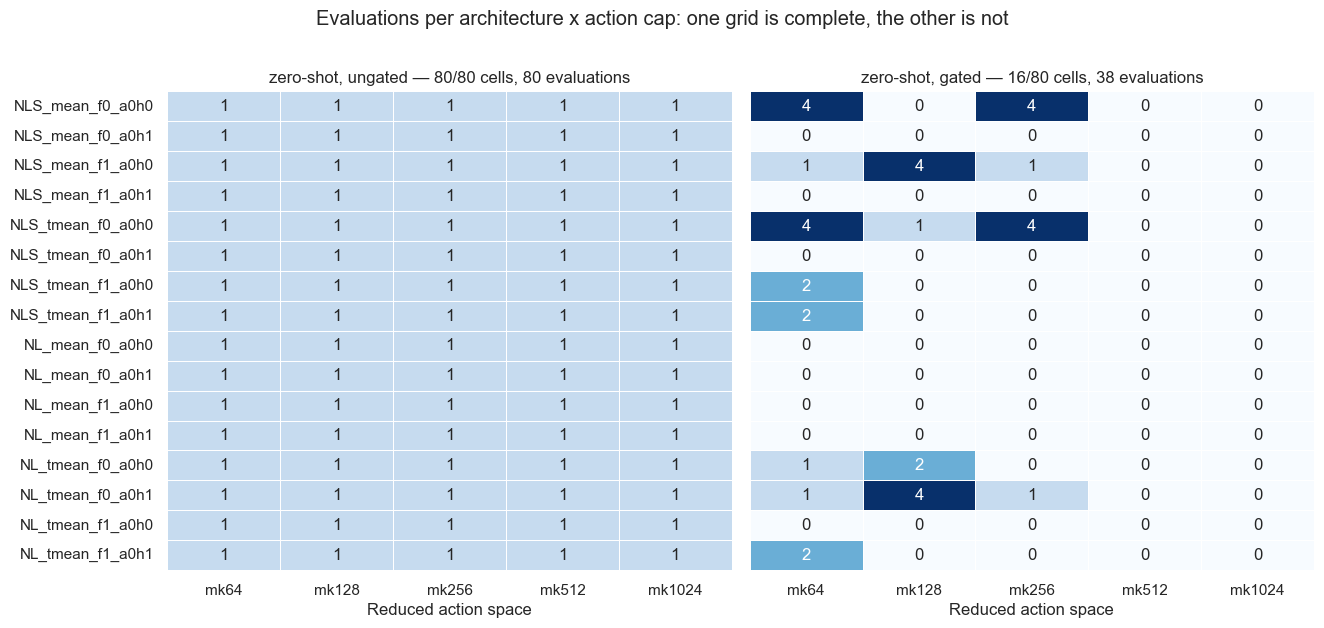

**The ungated zero-shot grid is a complete 16 x 5 factorial** — one evaluation in every cell, 80 in total. Every mean, every marginal and every matched pair taken on it is balanced by construction, and that is where Questions 1 and 3 do their work.

**The gated grid covers 16 of 80 cells**, with one to four rho thresholds in the cells it does cover and none at mk512 or mk1024. The best-covered cells are also the best-performing architectures, because that is how the screen was run — promising checkpoints got more thresholds. A `max` over this grid therefore rewards *attempts*, not only quality.

#### Every other route, by architecture and cap

mk                                                64   256
route                          variant                    
MAPPO fine-tune (aggressive)   NLS_mean_f0_a0h0     0    2
                               NLS_mean_f1_a0h0     0    6
MAPPO fine-tune (conservative) NLS_mean_f0_a0h0     2    0
                               NLS_mean_f0_a0h1     2    0
                               NLS_mean_f1_a0h0     2    0
                               NLS_mean_f1_a0h1     2    0
                               NLS_tmean_f0_a0h0    2    0
                               NLS_tmean_f0_a0h1    2    0
                               NLS_tmean_f1_a0h0    2    0
                               NLS_tmean_f1_a0h1    2    0
BC on greedy labels            NLS_mean_f1_a0h0     2    0

Each of these routes exists at **one** action cap, for **one to five** of the 16 architectures, and never for the same architecture as the others by design. Question 4 is where that bites, and it is handled there by comparing inside single cells rather than across the arms.

In [2]:
zero_all = runs.loc[runs["route"] == "bus14 zero-shot"]
CAPS, RHOS = W.caps_in(zero_all), [0.85, 0.90, 0.95, 1.00]
VARIANTS = sorted(runs["variant"].unique())


def coverage(frame):
    return (
        frame.pivot_table(index="variant", columns="mk", values="key",
                          aggfunc="size", fill_value=0, observed=True)
        .reindex(index=VARIANTS, columns=CAPS, fill_value=0)
    )


cover_ungated = coverage(zero_all.loc[zero_all["gate"] == "ungated"])
cover_gated = coverage(zero_all.loc[zero_all["gate"] == "gated"])

fig, axes = plt.subplots(1, 2, figsize=(13.4, 6.2), sharey=True)
for ax, grid, title in (
    (axes[0], cover_ungated, "zero-shot, ungated"),
    (axes[1], cover_gated, "zero-shot, gated"),
):
    sns.heatmap(grid, annot=True, fmt="d", cmap="Blues", vmin=0, vmax=4,
                linewidths=0.6, linecolor="white", cbar=False, ax=ax)
    filled = int((grid.to_numpy() > 0).sum())
    ax.set(xlabel="Reduced action space", ylabel="",
           title=f"{title} — {filled}/{grid.size} cells, {int(grid.to_numpy().sum())} evaluations")
    ax.set_xticklabels([f"mk{c}" for c in CAPS])
fig.suptitle("Evaluations per architecture x action cap: one grid is complete, the other is not",
             y=1.01)
fig.tight_layout()
save_figure(fig, "q0_coverage")
plt.show()

display(Markdown(
    f"**The ungated zero-shot grid is a complete {len(VARIANTS)} x {len(CAPS)} factorial** — "
    f"one evaluation in every cell, {int(cover_ungated.to_numpy().sum())} in total. Every mean, "
    f"every marginal and every matched pair taken on it is balanced by construction, and that "
    f"is where Questions 1 and 3 do their work.\n\n"
    f"**The gated grid covers {int((cover_gated.to_numpy() > 0).sum())} of {cover_gated.size} cells**, "
    f"with one to four rho thresholds in the cells it does cover and none at mk512 or mk1024. "
    f"The best-covered cells are also the best-performing architectures, because that is how "
    f"the screen was run — promising checkpoints got more thresholds. A `max` over this grid "
    f"therefore rewards *attempts*, not only quality."
))

display(Markdown("#### Every other route, by architecture and cap"))
display(
    runs.loc[runs["route"] != "bus14 zero-shot"]
    .pivot_table(index=["route", "variant"], columns="mk", values="key",
                 aggfunc="size", fill_value=0, observed=True)
)
display(Markdown(
    "Each of these routes exists at **one** action cap, for **one to five** of the 16 "
    "architectures, and never for the same architecture as the others by design. Question 4 "
    "is where that bites, and it is handled there by comparing inside single cells rather "
    "than across the arms."
))

## Question 1 — is scaling useful?

The transfer study runs each of its eight architecture cells under two input
conditions. `NL` keeps the original no-leak inputs: raw power channels and the
absolute voltage angle. `NLS` divides the power channels by each grid's own
maximum generator rating and replaces the absolute angle with the drop along
each line. Both are properties of the *source* training run, so a pair differs
in nothing else.

This is the correction the thesis plan singles out as one of the two things
transfer was expected to need, so it deserves a paired test rather than a
difference of group means: the two families are not evaluated at the same
caps and thresholds in equal numbers, and an unpaired comparison would mostly
measure that imbalance.

**44 matched cells** — same pooling, descriptor, idle head, cap and gate setting, differing only in the input condition.

Scaling is worth **+0.70 pp** of difficult-cohort survival on average (bootstrap CI over cells **[-0.91, +2.39]**), winning **26**, losing **18**, tying **0**.

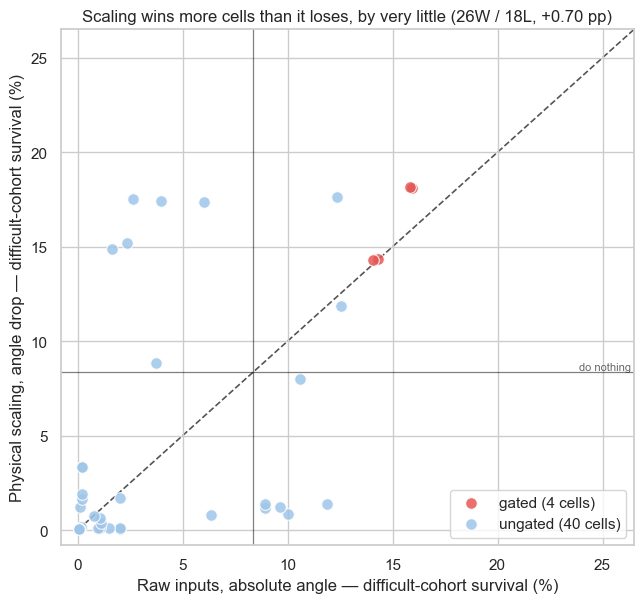

In [3]:
scaling_pairs = W.matched_pairs(
    runs.loc[runs["route"] == "bus14 zero-shot"],
    factor="scaling", levels=("raw inputs", "physical scaling"),
    within=["pool", "features", "head", "mk", "heuristic", "rho"],
)
mean_d, lo, hi = W.paired_bootstrap(scaling_pairs["delta"])
wins = int((scaling_pairs["delta"] > 0).sum())
losses = int((scaling_pairs["delta"] < 0).sum())
display(Markdown(
    f"**{len(scaling_pairs)} matched cells** — same pooling, descriptor, idle head, "
    f"cap and gate setting, differing only in the input condition.\n\n"
    f"Scaling is worth **{mean_d:+.2f} pp** of difficult-cohort survival on average "
    f"(bootstrap CI over cells **[{lo:+.2f}, {hi:+.2f}]**), winning "
    f"**{wins}**, losing **{losses}**, tying **{len(scaling_pairs) - wins - losses}**."
))

fig, ax = plt.subplots(figsize=(6.6, 6.2))
paired = scaling_pairs.assign(
    gate=np.where(scaling_pairs["heuristic"] == "none", "ungated", "gated")
)
for gate, group in paired.groupby("gate"):
    ax.scatter(group["raw inputs"], group["physical scaling"], s=70, alpha=0.85,
               color=W.GATE_COLORS[gate], edgecolor="white", linewidth=0.8,
               label=f"{gate} ({len(group)} cells)")
limit = max(paired[["raw inputs", "physical scaling"]].to_numpy().max(), 25) * 1.06
ax.plot([0, limit], [0, limit], color="#555555", linestyle="--", linewidth=1.2, zorder=0)
ax.axhline(DN_HARD, color="black", linewidth=0.9, alpha=0.5)
ax.axvline(DN_HARD, color="black", linewidth=0.9, alpha=0.5)
ax.text(limit, DN_HARD, "do nothing ", ha="right", va="bottom", fontsize=8, alpha=0.7)
ax.set(xlim=(-0.8, limit), ylim=(-0.8, limit),
       xlabel="Raw inputs, absolute angle — difficult-cohort survival (%)",
       ylabel="Physical scaling, angle drop — difficult-cohort survival (%)",
       title=f"Scaling wins more cells than it loses, by very little "
             f"({wins}W / {losses}L, {mean_d:+.2f} pp)")
ax.legend(loc="lower right")
fig.tight_layout()
save_figure(fig, "q1_scaling_paired")
plt.show()

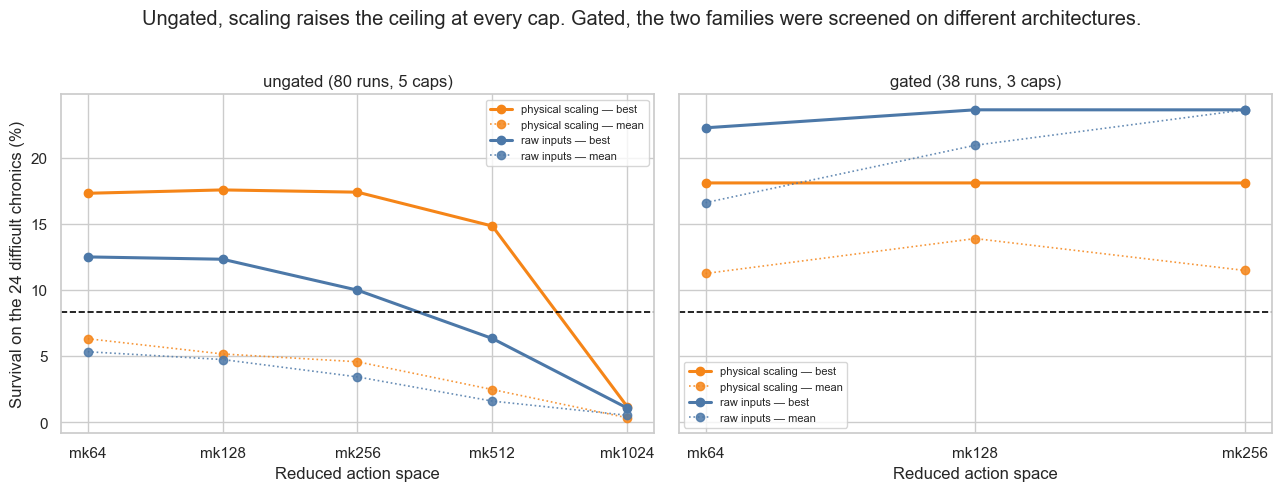

#### Difficult-cohort survival by input condition and gate

runs  hard_mean  hard_best  collapsed
gate    scaling                                                
gated   physical scaling    27      11.84      18.13          0
        raw inputs          11      19.65      23.67          0
ungated physical scaling    40       3.79      17.60         17
        raw inputs          40       3.14      12.53         16

Those group means are **not** a comparison: the two gate settings screened different architectures. Splitting the paired cells instead —

,gate,matched_cells,mean_pp,ci_low,ci_high,wins,losses
0,ungated,40,0.65,-1.13,2.53,22,18
1,gated,4,1.20,0.14,2.27,4,0


The gated raw-input group is almost entirely `NL_tmean_f0_a0h1`, the single strongest cell in the sweep, whose scaled twin was never evaluated with a gate. That is what makes the raw-input column look better gated, and it is an artifact of which checkpoints were screened — the four cells where both were actually run all favour scaling.

runs  hard_best
scaling          variant                           
physical scaling NLS_mean_f0_a0h0      8       6.21
                 NLS_mean_f1_a0h0      6      13.98
                 NLS_tmean_f0_a0h0     9      18.13
                 NLS_tmean_f1_a0h0     2      10.51
                 NLS_tmean_f1_a0h1     2      14.35
raw inputs       NL_tmean_f0_a0h0      3      15.91
                 NL_tmean_f0_a0h1      6      23.67
                 NL_tmean_f1_a0h1      2      14.30

In [4]:
zero = runs.loc[(runs["route"] == "bus14 zero-shot") & runs["hard_pct"].notna()]

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8), sharey=True)
for ax, gate in zip(axes, ["ungated", "gated"]):
    subset = zero.loc[zero["gate"] == gate]
    for scaling, group in subset.groupby("scaling", observed=True):
        stats = group.groupby("mk").agg(mean=("hard_pct", "mean"), best=("hard_pct", "max"))
        colour = W.SCALING_COLORS[scaling]
        ax.plot(stats.index, stats["best"], marker="o", linewidth=2.2, color=colour,
                label=f"{scaling} — best")
        ax.plot(stats.index, stats["mean"], marker="o", linewidth=1.2, linestyle=":",
                color=colour, alpha=0.85, label=f"{scaling} — mean")
    ax.axhline(DN_HARD, color="black", linestyle="--", linewidth=1.2)
    caps = sorted(subset["mk"].unique())
    ax.set(xscale="log", xlabel="Reduced action space",
           title=f"{gate} ({len(subset)} runs, {len(caps)} caps)")
    ax.set_xticks(caps, [f"mk{int(m)}" for m in caps])
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.legend(fontsize=8)
axes[0].set_ylabel(f"Survival on the {N_HARD} difficult chronics (%)")
fig.suptitle("Ungated, scaling raises the ceiling at every cap. Gated, the two "
             "families were screened on different architectures.", y=1.02)
fig.tight_layout()
save_figure(fig, "q1_scaling_by_cap")
plt.show()

display(Markdown("#### Difficult-cohort survival by input condition and gate"))
display(
    zero.groupby(["gate", "scaling"], observed=True).agg(
        runs=("key", "size"), hard_mean=("hard_pct", "mean"),
        hard_best=("hard_pct", "max"), collapsed=("collapsed", "sum"),
    )
)
display(Markdown(
    "Those group means are **not** a comparison: the two gate settings screened "
    "different architectures. Splitting the paired cells instead —"
))
gate_split = []
for gate in ["ungated", "gated"]:
    pairs = W.matched_pairs(
        zero.loc[zero["gate"] == gate], "scaling", ("raw inputs", "physical scaling"),
        ["pool", "features", "head", "mk", "heuristic", "rho"],
    )
    mean_g, lo_g, hi_g = W.paired_bootstrap(pairs["delta"])
    gate_split.append({"gate": gate, "matched_cells": len(pairs), "mean_pp": mean_g,
                       "ci_low": lo_g, "ci_high": hi_g,
                       "wins": int((pairs["delta"] > 0).sum()),
                       "losses": int((pairs["delta"] < 0).sum())})
display(pd.DataFrame(gate_split))
display(Markdown(
    "The gated raw-input group is almost entirely `NL_tmean_f0_a0h1`, the single "
    "strongest cell in the sweep, whose scaled twin was never evaluated with a gate. "
    "That is what makes the raw-input column look better gated, and it is an artifact "
    "of which checkpoints were screened — the four cells where both were actually run "
    "all favour scaling."
))
display(zero.loc[zero["gate"] == "gated"].groupby(["scaling", "variant"], observed=True)
        .agg(runs=("key", "size"), hard_best=("hard_pct", "max")))

### Answer

**Keep it — but it is not the lever, and it is not what makes transfer work.**

Across all 44 matched cells physical scaling is worth **+0.70 pp** of
difficult-cohort survival, with a bootstrap interval over cells of
**[−0.91, +2.39]** that comfortably contains zero. It wins 26 cells and loses
18. On this evidence the correction is real but small, and a single seed per
cell cannot resolve it.

Two details matter more than the headline.

*The ungated ceiling.* Where nothing protects the policy, scaling is what stands
between it and its worst case: the best scaled zero-shot run reaches **17.6 %**
on the difficult cohort against **12.5 %** for the best raw run, and holds that
margin from mk64 to mk512. That is exactly what the correction is for — it stops
the target grid's larger power magnitudes from leaving the range the encoder was
trained on — and it is the condition in which that would bite hardest.

*The gated comparison is not what the group means suggest.* Gated raw-input runs
average 19.7 % against 11.8 % for gated scaled runs, which looks like a reversal
and is not one. Almost every gated raw-input run is `NL_tmean_f0_a0h1`, the
strongest cell in the sweep, whose scaled twin was never screened with a gate.
Restricted to the **four** cells where both were actually run, scaling wins all
four, by +0.05 to +2.31 pp. Four pairs decide nothing, but they certainly do not
argue against the correction.

So: keep it. It costs nothing at evaluation time, it is the right correction on
first principles, and the evidence is weakly positive everywhere it is paired
and negative nowhere. It is simply not the factor that decides whether transfer
works — Questions 2 and 3 have larger effects, and the evaluation gate in
Question 4 is larger than all of them.

## Question 2 — what action reduction should be used?

$k$ caps the number of topology actions each agent may choose from. It is not a
free parameter: it moves the greedy oracle's ceiling as much as it moves the
policy, so raw survival cannot be compared across caps. The left panel shows
what the policy achieves, the right shows what fraction of the reachable
headroom that is — and the collapse count, the number of runs that lose the
grid within a handful of steps.

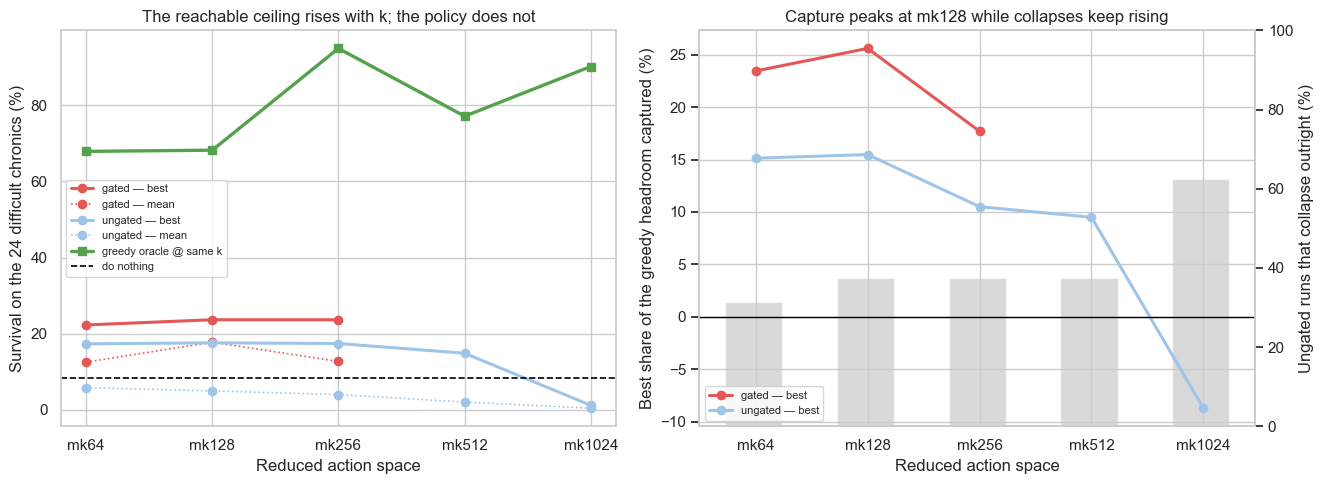

#### Zero-shot transfer by cap and gate

runs  hard_mean  hard_best  capture_best  rescues_best  collapsed
gate    mk                                                                     
gated   64      17      12.54      22.30         23.45          4.00          0
        128     11      17.77      23.67         25.61          4.00          0
        256     10      12.72      23.66         17.70          4.00          0
ungated 64      16       5.85      17.35         15.13          1.00          5
        128     16       4.97      17.60         15.48          3.00          6
        256     16       4.02      17.43         10.50          3.00          6
        512     16       2.05      14.87          9.49          1.00          6
        1024    16       0.45       1.20         -8.73          0.00         10

#### The same peak, re-derived on balanced subsets

**3 architectures** were gated at all three caps (`NLS_mean_f1_a0h0`, `NLS_tmean_f0_a0h0`, `NL_tmean_f0_a0h1`). Restricting to them removes the unequal-attempts problem; fixing the threshold at rho = 0.95 as well removes the unequal-threshold-search problem.

mk,64,128,256
unbalanced best (as plotted),23.45,25.61,17.70
balanced: 3 covered variants,15.36,17.13,11.54
balanced + rho fixed at 0.95,15.36,16.06,11.26


Both restrictions preserve the ordering **mk128 > mk64 > mk256**, and **2 of 3** covered architectures pick mk128 individually — the third picks mk64, none picks mk256. What the unbalanced view inflates is the *magnitude*: the headline 25.6 % is the best threshold of the best architecture, and the balanced mean is closer to 16 %.

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.0))

for gate, group in zero.groupby("gate", observed=True):
    stats = group.groupby("mk").agg(mean=("hard_pct", "mean"), best=("hard_pct", "max"))
    colour = W.GATE_COLORS[gate]
    axes[0].plot(stats.index, stats["best"], marker="o", linewidth=2.2, color=colour,
                 label=f"{gate} — best")
    axes[0].plot(stats.index, stats["mean"], marker="o", linewidth=1.2, linestyle=":",
                 color=colour, label=f"{gate} — mean")
greedy = data.greedy_ceiling.loc[data.greedy_ceiling["mk"].isin(W.caps_in(zero))]
axes[0].plot(greedy["mk"], greedy["greedy_hard_pct"], marker="s", color="#54A24B",
             linewidth=2.4, label="greedy oracle @ same k")
axes[0].axhline(DN_HARD, color="black", linestyle="--", linewidth=1.2, label="do nothing")
axes[0].set(ylabel=f"Survival on the {N_HARD} difficult chronics (%)",
            title="The reachable ceiling rises with k; the policy does not")

for gate, group in zero.groupby("gate", observed=True):
    stats = group.groupby("mk").agg(best=("capture_hard_pct", "max"))
    axes[1].plot(stats.index, stats["best"], marker="o", linewidth=2.2,
                 color=W.GATE_COLORS[gate], label=f"{gate} — best")
collapse = zero.loc[zero["gate"] == "ungated"].groupby("mk").agg(
    runs=("key", "size"), collapsed=("collapsed", "sum"))
twin = axes[1].twinx()
twin.bar(collapse.index, 100 * collapse["collapsed"] / collapse["runs"],
         width=[0.35 * m for m in collapse.index], color="#BBBBBB", alpha=0.55, zorder=0)
twin.set(ylabel="Ungated runs that collapse outright (%)", ylim=(0, 100))
twin.grid(False)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(ylabel="Best share of the greedy headroom captured (%)",
            title="Capture peaks at mk128 while collapses keep rising")
axes[1].set_zorder(twin.get_zorder() + 1)
axes[1].patch.set_visible(False)

for ax in axes:
    ax.set_xscale("log", base=2)
    ax.set_xticks(W.caps_in(zero), [f"mk{m}" for m in W.caps_in(zero)])
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.set_xlabel("Reduced action space")
axes[0].legend(fontsize=8, loc="center left")
axes[1].legend(fontsize=8, loc="lower left")
fig.tight_layout()
save_figure(fig, "q2_action_reduction")
plt.show()

display(Markdown("#### Zero-shot transfer by cap and gate"))
display(
    zero.groupby(["gate", "mk"], observed=True).agg(
        runs=("key", "size"),
        hard_mean=("hard_pct", "mean"), hard_best=("hard_pct", "max"),
        capture_best=("capture_hard_pct", "max"),
        rescues_best=("hard_rescues", "max"),
        collapsed=("collapsed", "sum"),
    )
)

# The gated row of that table is drawn from the unbalanced grid of section 0, so
# the peak is re-derived twice under stricter matching before it is believed.
gated_zero = zero.loc[zero["gate"] == "gated"]
covered = gated_zero.groupby("variant")["mk"].nunique()
covered = covered[covered == gated_zero["mk"].nunique()].index.tolist()
balanced = gated_zero.loc[gated_zero["variant"].isin(covered)]
by_variant = balanced.pivot_table(index="variant", columns="mk",
                                  values="capture_hard_pct", aggfunc="max")
fixed_rho = (
    gated_zero.loc[np.isclose(gated_zero["rho"], 0.95)]
    .pivot_table(index="variant", columns="mk", values="capture_hard_pct", aggfunc="max")
    .dropna()
)
display(Markdown(
    f"#### The same peak, re-derived on balanced subsets\n\n"
    f"**{len(covered)} architectures** were gated at all three caps "
    f"(`{'`, `'.join(covered)}`). Restricting to them removes the "
    f"unequal-attempts problem; fixing the threshold at rho = 0.95 as well removes the "
    f"unequal-threshold-search problem."
))
display(pd.DataFrame({
    "unbalanced best (as plotted)": gated_zero.groupby("mk")["capture_hard_pct"].max(),
    "balanced: 3 covered variants": by_variant.mean(),
    "balanced + rho fixed at 0.95": fixed_rho.mean(),
}).T)
display(Markdown(
    "Both restrictions preserve the ordering **mk128 > mk64 > mk256**, and "
    f"**{sum(int(by_variant.loc[v].idxmax()) == 128 for v in by_variant.index)} of "
    f"{len(by_variant)}** covered architectures pick mk128 individually — the third picks "
    "mk64, none picks mk256. What the unbalanced view inflates is the *magnitude*: the "
    "headline 25.6 % is the best threshold of the best architecture, and the balanced mean "
    "is closer to 16 %."
))

### Answer

**mk128, and never above mk256.** Two things move in opposite directions as the
cap grows. The oracle's ceiling climbs — from 67.9 % of the difficult cohort at
mk64 to 94.9 % at mk256 — because a larger candidate set genuinely contains
better actions. The policy's ability to find them falls: ungated difficult-cohort
survival decays monotonically from 5.9 % at mk64 to 0.5 % at mk1024, and by
mk1024 ten of sixteen architecture variants collapse outright.

Normalising by the moving ceiling makes the peak unambiguous. The best gated run
captures **25.6 %** of the reachable headroom at mk128, against 23.5 % at mk64
and 17.7 % at mk256 — the same policies, scored against what was actually
reachable with the candidates they were given. Below mk128 the ceiling itself is
the binding constraint; above it, the scorer is.

mk1024 is not a setting to tune, it is a setting to avoid: every ungated run
there lands below the do-nothing floor.

## Question 3 — what model performs best?

Three binary choices vary inside the shared candidate-scoring design, alongside
the input condition of Question 1:

* **pooling** — a joint mean over the touched-node embeddings, or one mean per
  node type concatenated (`typed-mean`);
* **descriptor** — whether the static features of a candidate action are fed to
  the scorer alongside the pooled embedding;
* **idle head** — whether do-nothing is scored by the shared scorer like any
  other candidate, or by a dedicated head.

Each is measured the same way as Question 1: paired within every cell that
differs only in that one factor, on the zero-shot arm where all 16 variants were
evaluated at all five caps.

,factor,contrast,cells,mean_pp,ci_low,ci_high,wins,losses
0,scaling,physical scaling - raw inputs,44,0.70,-0.91,2.39,26,18
1,pooling,typed-mean pool - mean pool,49,3.84,1.60,6.00,34,15
2,descriptor,descriptor on - descriptor off,45,0.64,-1.46,2.73,29,16
3,idle,dedicated idle head - shared idle scorer,45,-1.04,-3.00,0.76,23,17


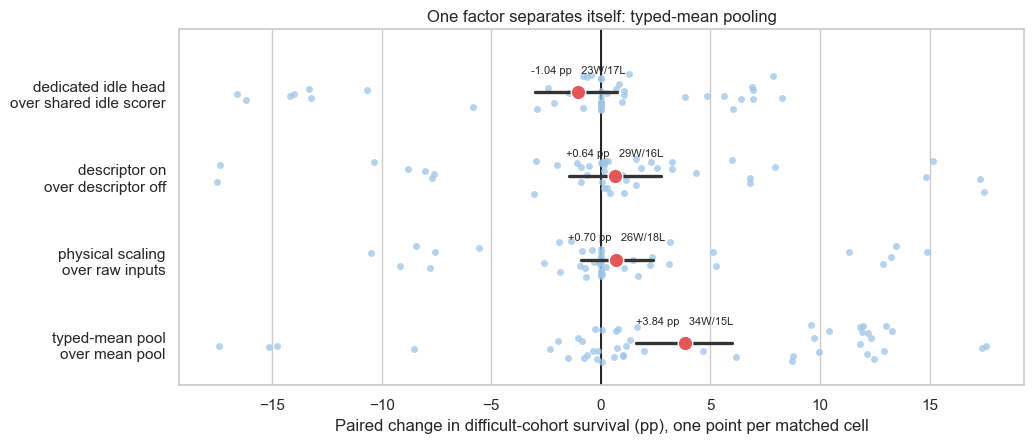

In [6]:
factor_specs = [
    ("scaling", ("raw inputs", "physical scaling"), ["pool", "features", "head", "mk", "heuristic", "rho"]),
    ("pooling", ("mean pool", "typed-mean pool"), ["family", "features", "head", "mk", "heuristic", "rho"]),
    ("descriptor", ("descriptor off", "descriptor on"), ["family", "pool", "head", "mk", "heuristic", "rho"]),
    ("idle", ("shared idle scorer", "dedicated idle head"), ["family", "pool", "features", "mk", "heuristic", "rho"]),
]
zero_all = runs.loc[runs["route"] == "bus14 zero-shot"]

summary_rows, delta_frames = [], []
for factor, levels, within in factor_specs:
    pairs = W.matched_pairs(zero_all, factor, levels, within)
    mean_d, lo, hi = W.paired_bootstrap(pairs["delta"])
    label = f"{levels[1]}\nover {levels[0]}"
    summary_rows.append({
        "factor": factor, "contrast": f"{levels[1]} - {levels[0]}", "cells": len(pairs),
        "mean_pp": mean_d, "ci_low": lo, "ci_high": hi,
        "wins": int((pairs["delta"] > 0).sum()), "losses": int((pairs["delta"] < 0).sum()),
    })
    delta_frames.append(pd.DataFrame({"label": label, "delta": pairs["delta"].to_numpy()}))
factor_summary = pd.DataFrame(summary_rows)
deltas = pd.concat(delta_frames, ignore_index=True)
display(factor_summary)

order = factor_summary.sort_values("mean_pp")["contrast"].tolist()
label_order = [f"{c.split(' - ')[0]}\nover {c.split(' - ')[1]}" for c in order]

fig, ax = plt.subplots(figsize=(10.5, 4.6))
np.random.seed(0)  # seaborn's jitter draws from the global stream; keep re-runs identical
sns.stripplot(data=deltas, x="delta", y="label", order=label_order, orient="h",
              color="#9EC5E8", size=5, alpha=0.75, jitter=0.22, ax=ax)
for row in factor_summary.itertuples():
    y = label_order.index(f"{row.contrast.split(' - ')[0]}\nover {row.contrast.split(' - ')[1]}")
    ax.plot([row.ci_low, row.ci_high], [y, y], color="#333333", linewidth=2.4, zorder=3)
    ax.scatter([row.mean_pp], [y], color="#E45756", s=110, zorder=4, edgecolor="white",
               linewidth=1.0)
    ax.annotate(f"{row.mean_pp:+.2f} pp   {row.wins}W/{row.losses}L", (row.mean_pp, y),
                xytext=(0, 14), textcoords="offset points", ha="center", fontsize=8)
ax.axvline(0, color="black", linewidth=1.2)
ax.set_ylim(len(label_order) - 0.5, -0.75)  # headroom for the topmost annotation
ax.set(xlabel="Paired change in difficult-cohort survival (pp), one point per matched cell",
       ylabel="", title="One factor separates itself: typed-mean pooling")
fig.tight_layout()
save_figure(fig, "q3_factor_effects")
plt.show()

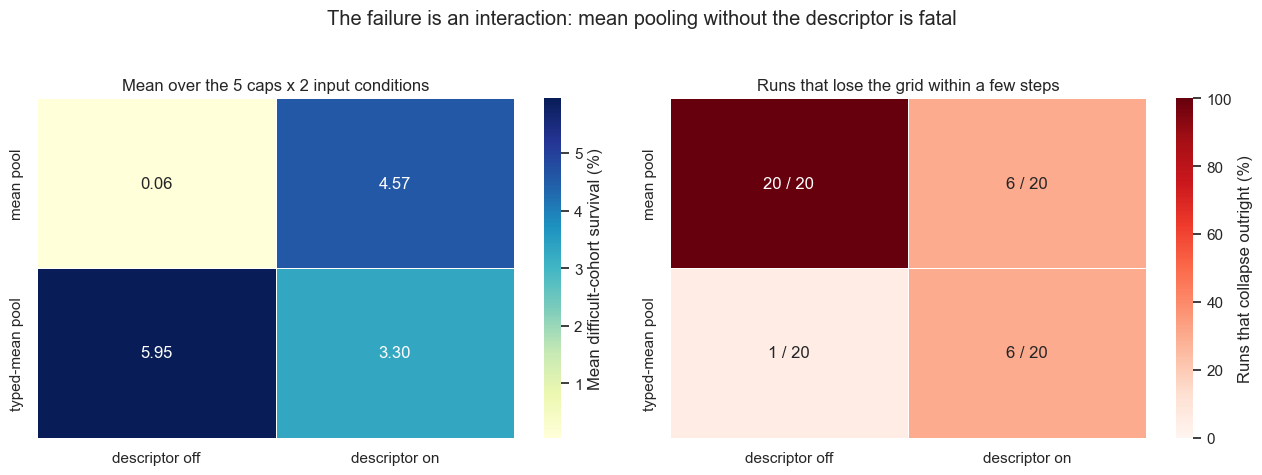

#### The 16 variants, ranked on the ungated zero-shot grid

caps  hard_mean  hard_best  collapsed
scaling          pooling         descriptor     idle                                                      
physical scaling mean pool       descriptor on  shared idle scorer      5      13.07      17.52          1
                 typed-mean pool descriptor off shared idle scorer      5       9.66      17.60          0
raw inputs       typed-mean pool descriptor on  dedicated idle head     5       7.00      10.60          1
                                 descriptor off dedicated idle head     5       6.93      11.89          0
                                                shared idle scorer      5       6.15      12.53          0
                 mean pool       descriptor on  shared idle scorer      5       2.75       6.04          0
physical scaling typed-mean pool descriptor on  dedicated idle head     5       2.29       8.00          1
                 mean pool       descriptor on  dedicated idle head     5       2.29       3.33          0
raw inputs       typed-mean pool descriptor on  shared idle scorer      5       2.04       3.72          0
physical scaling typed-mean pool descriptor on  shared idle scorer      5       1.85       8.83          4
                                 descriptor off dedicated idle head     5       1.06       1.71          1
raw inputs       mean pool       descriptor on  dedicated idle head     5       0.19       0.21          5
physical scaling mean pool       descriptor off dedicated idle head     5       0.07       0.07          5
                                                shared idle scorer      5       0.05       0.05          5
raw inputs       mean pool       descriptor off dedicated idle head     5       0.05       0.05          5
                                                shared idle scorer      5       0.05       0.05          5

In [7]:
zero_ungated = zero_all.loc[zero_all["gate"] == "ungated"]
grid = zero_ungated.pivot_table(index="pooling", columns="descriptor",
                                values="hard_pct", aggfunc="mean", observed=True)
collapse_grid = zero_ungated.pivot_table(index="pooling", columns="descriptor",
                                         values="collapsed", aggfunc="sum", observed=True)
counts = zero_ungated.pivot_table(index="pooling", columns="descriptor",
                                  values="key", aggfunc="size", observed=True)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6))
sns.heatmap(grid, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.6, linecolor="white",
            cbar_kws={"label": "Mean difficult-cohort survival (%)"}, ax=axes[0])
axes[0].set(title="Mean over the 5 caps x 2 input conditions", xlabel="", ylabel="")
annotated = collapse_grid.astype(str) + " / " + counts.astype(str)
sns.heatmap(collapse_grid / counts * 100, annot=annotated.to_numpy(), fmt="", cmap="Reds",
            linewidths=0.6, linecolor="white", vmin=0, vmax=100,
            cbar_kws={"label": "Runs that collapse outright (%)"}, ax=axes[1])
axes[1].set(title="Runs that lose the grid within a few steps", xlabel="", ylabel="")
fig.suptitle("The failure is an interaction: mean pooling without the descriptor is fatal", y=1.03)
fig.tight_layout()
save_figure(fig, "q3_pooling_interaction")
plt.show()

display(Markdown("#### The 16 variants, ranked on the ungated zero-shot grid"))
display(
    zero_ungated.groupby(["scaling", "pooling", "descriptor", "idle"], observed=True)
    .agg(caps=("mk", "nunique"), hard_mean=("hard_pct", "mean"),
         hard_best=("hard_pct", "max"), collapsed=("collapsed", "sum"))
    .sort_values("hard_mean", ascending=False)
)

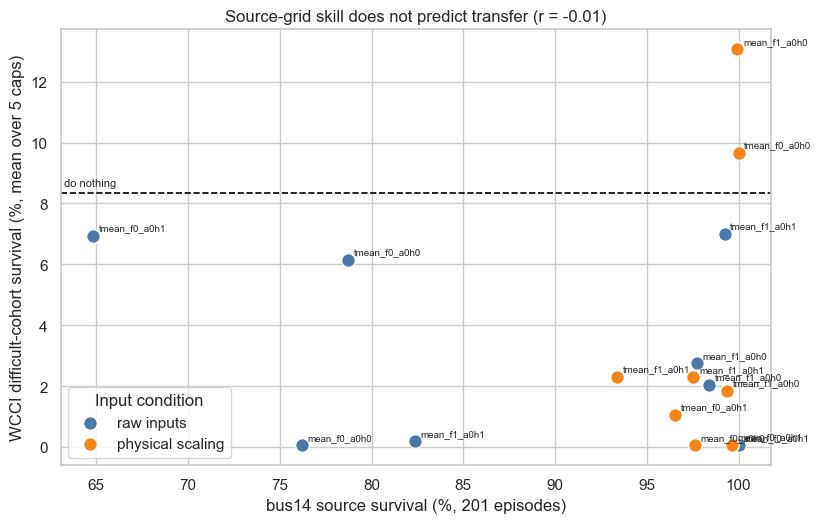

In [8]:
link = (
    zero_ungated.groupby("variant", as_index=False, observed=True)
    .agg(wcci_hard_mean=("hard_pct", "mean"), wcci_hard_best=("hard_pct", "max"))
    .merge(data.bus14, on="variant", how="inner")
)
correlation = link[["bus14_pct", "wcci_hard_mean"]].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(8.4, 5.4))
for family, group in link.groupby(link["variant"].str.split("_").str[0]):
    ax.scatter(group["bus14_pct"], group["wcci_hard_mean"], s=95, edgecolor="white",
               linewidth=0.9, label=W.SCALING_LABELS[family],
               color=W.SCALING_COLORS[W.SCALING_LABELS[family]])
for row in link.itertuples():
    ax.annotate(row.variant.split("_", 1)[1], (row.bus14_pct, row.wcci_hard_mean),
                xytext=(4, 4), textcoords="offset points", fontsize=7)
ax.axhline(DN_HARD, color="black", linestyle="--", linewidth=1.2)
ax.text(ax.get_xlim()[0], DN_HARD + 0.25, " do nothing", fontsize=8)
ax.set(xlabel="bus14 source survival (%, 201 episodes)",
       ylabel="WCCI difficult-cohort survival (%, mean over 5 caps)",
       title=f"Source-grid skill does not predict transfer (r = {correlation:+.2f})")
ax.legend(title="Input condition", loc="lower left")
fig.tight_layout()
save_figure(fig, "q3_source_vs_transfer")
plt.show()

### Answer

**Typed-mean pooling, and it is the only one of the three that is not noise.**

Switching a matched cell from a joint mean to a per-type mean is worth
**+3.84 pp** of difficult-cohort survival, CI **[+1.60, +6.00]**, winning 34
cells to 15 — the only factor in the sweep whose interval clears zero. The
action descriptor (+0.64 pp) and the idle head (−1.04 pp for the dedicated
version, i.e. a mild preference for the shared scorer) are indistinguishable
from noise on this evidence, and so is the input condition from Question 1.

The heat map shows why the marginals understate pooling, and it is more
interesting than a main effect. The two factors **cross**:

* mean pooling **without** the descriptor is fatal — **20 of 20** ungated runs
  collapse, mean difficult-cohort survival 0.06 %. With nothing but a joint
  pooled vector, candidates that touch the same nodes are literally
  indistinguishable to the scorer, so it has nothing to rank.
* mean pooling **with** the descriptor recovers to 4.57 % and 6 of 20 collapses:
  the descriptor supplies the missing identity.
* typed-mean pooling is the reverse — best **without** the descriptor (5.95 %,
  1 of 20 collapses) and *worse* with it (3.30 %, 6 of 20).

Read together: what the scorer needs is a way to tell candidates apart, and the
two factors are competing ways of supplying it. Typed-mean pooling supplies it
structurally and better; adding the descriptor on top makes things worse.
The best single configuration in the ungated grid is the scaled mean-pool cell
with the descriptor (13.07 % mean over five caps) — which is the exception, from
one seed, and is why the ranking table is shown in full rather than summarised.

The last plot is the uncomfortable one. Across the 16 variants, bus14 test
survival and WCCI difficult-cohort survival are **uncorrelated** (r = −0.01).
Selecting a checkpoint on the source grid is not selecting for transfer — and
every checkpoint in this study was selected that way. That does not invalidate
the comparisons above, all of which are made on the target grid, but it does
mean the *pool* they were drawn from was assembled on an irrelevant criterion.

## Question 4 — is fine-tuning useful, and what kind?

Four routes spend target-grid gradient steps on the transferred actor, against a
zero-shot arm that spends none:

| route | what it optimises | budget consumed |
|---|---|---|
| **MAPPO fine-tune (aggressive)** | WCCI return, actor restarted at `1e-4`, fully unfrozen, mk256 | see table |
| **MAPPO fine-tune (conservative)** | same, with an annealed actor lr, gentler PPO updates, mk64 | see table |
| **BC on greedy labels** | supervised imitation of the one-step greedy oracle, on dangerous states only | — |
| **MAPPO scratch** | WCCI return from random initialisation — the control that says whether transfer is worth anything | see table |

mk64 is the only cap where all of them were evaluated, and it is where the
comparison has to be made. Note the constraint from §0: apart from the
aggressive arm, none of these have per-episode artifacts, so this section runs
on `overall_pct`, where 26 of 50 episodes are free and every difference is
roughly halved relative to the difficult cohort.

In [9]:
STEP_MEANING = {
    "bus14 zero-shot": "bus14 steps (no target training)",
    "MAPPO fine-tune (aggressive)": "WCCI steps of 15M",
    "MAPPO fine-tune (conservative)": "WCCI steps of 15M",
    "BC on greedy labels": "bus14 steps of the distilled source (no PPO on WCCI)",
    "MAPPO scratch": "WCCI steps of 15M",
}
STEP_MEANING = {k: v for k, v in STEP_MEANING.items() if k in set(runs["route"])}
budget = runs.groupby("route", observed=True).agg(
    runs=("key", "size"), scored=("hard_pct", "count"),
    caps=("mk", lambda s: ", ".join(f"mk{int(m)}" for m in sorted(set(s.dropna())))),
    min_step=("checkpoint_step", "min"), max_step=("checkpoint_step", "max"),
).dropna(how="all")
budget.insert(2, "step count is", [STEP_MEANING[r] for r in budget.index])
display(Markdown("#### What each route actually spent"))
display(budget)
display(Markdown(
    "The step column does not mean the same thing in every row, which is why it is "
    "labelled. Zero-shot carries its **bus14** count: no gradient ever touched the "
    "target grid. BC carries the step of the bus14 checkpoint it distilled; its own "
    "budget is supervised epochs, not PPO steps. Only the three RL-on-WCCI rows are "
    "target-grid budgets, and **none of them is finished**: the aggressive arm stopped "
    "at 0.17M and 1.41M of 15M, the conservative arm at 4.98M, and the scratch control "
    "— the one that is supposed to say whether transfer is worth anything — at "
    "**0.17M, about 1 % of its budget**. Every comparison below inherits that."
))

#### What each route actually spent

,runs,scored,step count is,caps,min_step,max_step
route,,,,,,
bus14 zero-shot,118,118,bus14 steps (no target training),"mk64, mk128, mk256, mk512, mk1024",8709120,14929920
MAPPO fine-tune (aggressive),8,8,WCCI steps of 15M,mk256,165888,1410048
MAPPO fine-tune (conservative),16,0,WCCI steps of 15M,mk64,4976640,4976640
BC on greedy labels,2,0,bus14 steps of the distilled source (no PPO on...,mk64,14929920,14929920


The step column does not mean the same thing in every row, which is why it is labelled. Zero-shot carries its **bus14** count: no gradient ever touched the target grid. BC carries the step of the bus14 checkpoint it distilled; its own budget is supervised epochs, not PPO steps. Only the three RL-on-WCCI rows are target-grid budgets, and **none of them is finished**: the aggressive arm stopped at 0.17M and 1.41M of 15M, the conservative arm at 4.98M, and the scratch control — the one that is supposed to say whether transfer is worth anything — at **0.17M, about 1 % of its budget**. Every comparison below inherits that.

### The comparison that cannot be made, and the one that can

The obvious chart — best run of each route at mk64 — is exactly the trap section
0 warns about. Each route's "best" is a different architecture, found after a
different number of attempts: zero-shot chose from 16 architectures and up to
four thresholds, the scratch control had one architecture and one evaluation.
It is shown first because it is the number that gets quoted, and then it is
discarded.

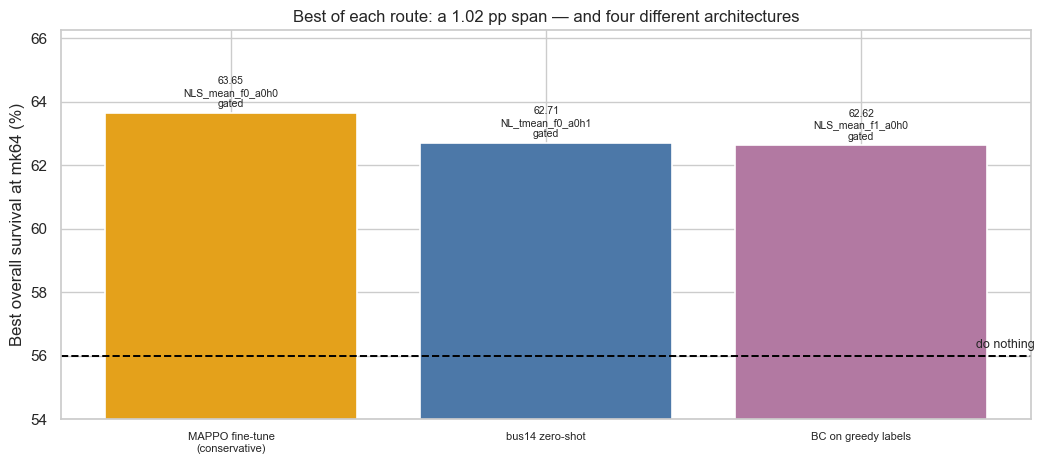

Every bar is a different architecture and the gate setting is not held fixed either. The 1.02 pp span is not a route effect — it is four arms that were each given a different number of chances to produce a maximum. **Do not quote it.**

In [10]:
mk64 = runs.loc[runs["mk"] == 64].copy()
best64 = (
    mk64.sort_values("overall_pct", ascending=False)
    .groupby("route", observed=True).head(1)
    .sort_values("overall_pct", ascending=False)
)

fig, ax = plt.subplots(figsize=(10.6, 4.8))
labels = [r.route.replace(" (", "\n(") for r in best64.itertuples()]
bars = ax.bar(labels, best64["overall_pct"],
              color=[W.ROUTE_COLORS[r.route] for r in best64.itertuples()],
              edgecolor="white", linewidth=1.2)
for bar, row in zip(bars, best64.itertuples()):
    ax.annotate(f"{row.overall_pct:.2f}\n{row.variant}\n{row.gate}",
                (bar.get_x() + bar.get_width() / 2, row.overall_pct),
                xytext=(0, 4), textcoords="offset points", ha="center", fontsize=7.5)
ax.axhline(DN_OVERALL, color="black", linestyle="--", linewidth=1.4)
ax.text(len(labels) - 0.45, DN_OVERALL + 0.25, "do nothing", ha="right", fontsize=9)
span = best64["overall_pct"].max() - best64["overall_pct"].min()
ax.set(ylim=(54, best64["overall_pct"].max() + 2.6),
       ylabel="Best overall survival at mk64 (%)",
       title=f"Best of each route: a {span:.2f} pp span — and four different architectures")
ax.tick_params(axis="x", labelsize=8)
fig.tight_layout()
save_figure(fig, "q4_uncontrolled")
plt.show()

display(Markdown(
    f"Every bar is a different architecture and the gate setting is not held fixed either. "
    f"The {span:.2f} pp span is not a route effect — it is four arms that were each given a "
    f"different number of chances to produce a maximum. **Do not quote it.**"
))

Nine `architecture x cap x gate` cells contain more than one route. Inside one
of those, the architecture, the action set, the seed and the gate are all fixed
and the *only* thing that changes is where the target-grid gradient came from.
That is the comparison, and it says something quite different.

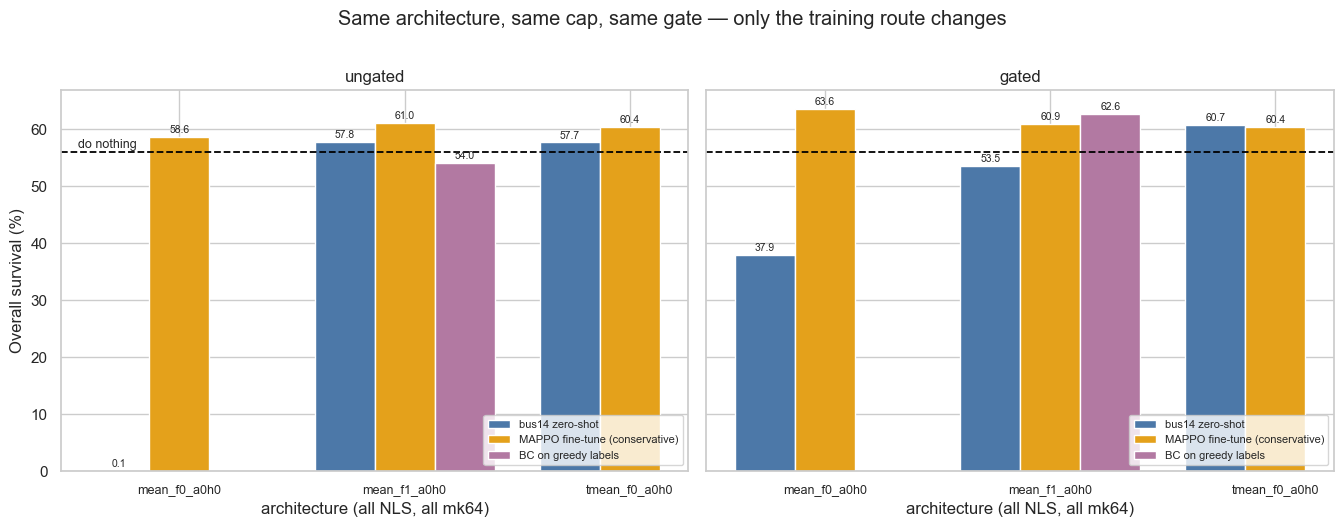

#### Every controlled contrast against zero-shot in the whole dataset

,variant,mk,gate,route,zero_shot_pct,route_pct,gain_pp
12,NLS_tmean_f0_a0h1,64,ungated,MAPPO fine-tune (conservative),0.80,61.15,60.35
1,NLS_mean_f0_a0h0,64,ungated,MAPPO fine-tune (conservative),0.05,58.58,58.52
9,NLS_mean_f1_a0h1,64,ungated,MAPPO fine-tune (conservative),1.92,59.49,57.57
3,NLS_mean_f0_a0h1,64,ungated,MAPPO fine-tune (conservative),0.07,56.96,56.89
2,NLS_mean_f0_a0h0,256,gated,MAPPO fine-tune (aggressive),37.77,63.59,25.83
0,NLS_mean_f0_a0h0,64,gated,MAPPO fine-tune (conservative),37.89,63.65,25.76
4,NLS_mean_f1_a0h0,64,gated,BC on greedy labels,53.52,62.62,9.10
16,NLS_tmean_f1_a0h1,64,ungated,MAPPO fine-tune (conservative),51.95,60.83,8.88
8,NLS_mean_f1_a0h0,256,gated,MAPPO fine-tune (aggressive),54.09,62.51,8.43
13,NLS_tmean_f1_a0h0,64,gated,MAPPO fine-tune (conservative),52.79,61.02,8.22


**15 of 17** controlled contrasts favour target-grid training, by a median of **+8.43 pp** and a maximum of **+60.35 pp** — against the 1.02 pp the uncontrolled chart reported.

#### The range, from the architectures that transfer worst to the ones that transfer best

,variant,mk,gate,route,zero_shot_pct,route_pct,gain_pp
12,NLS_tmean_f0_a0h1,64,ungated,MAPPO fine-tune (conservative),0.80,61.15,60.35
1,NLS_mean_f0_a0h0,64,ungated,MAPPO fine-tune (conservative),0.05,58.58,58.52
9,NLS_mean_f1_a0h1,64,ungated,MAPPO fine-tune (conservative),1.92,59.49,57.57
11,NLS_tmean_f0_a0h0,64,ungated,MAPPO fine-tune (conservative),57.69,60.38,2.69
10,NLS_tmean_f0_a0h0,64,gated,MAPPO fine-tune (conservative),60.70,60.37,-0.33
7,NLS_mean_f1_a0h0,64,ungated,BC on greedy labels,57.77,54.02,-3.75


#### And the gate, controlled the same way — 25 cells where one route x architecture x cap was evaluated both ways

gate,route,variant,mk,ungated,gated,delta
24,bus14 zero-shot,NLS_mean_f0_a0h0,64,0.05,37.89,37.84
23,bus14 zero-shot,NLS_mean_f0_a0h0,256,0.05,37.77,37.72
22,bus14 zero-shot,NL_tmean_f0_a0h0,128,40.05,59.59,19.55
21,BC on greedy labels,NLS_mean_f1_a0h0,64,54.02,62.62,8.61
20,bus14 zero-shot,NL_tmean_f0_a0h1,256,54.99,63.36,8.37
19,bus14 zero-shot,NLS_tmean_f1_a0h1,64,51.95,58.89,6.94
18,bus14 zero-shot,NL_tmean_f0_a0h1,64,56.42,62.71,6.28
17,bus14 zero-shot,NL_tmean_f1_a0h1,64,49.75,55.99,6.24
16,bus14 zero-shot,NL_tmean_f0_a0h1,128,57.70,63.36,5.66
15,MAPPO fine-tune (conservative),NLS_mean_f0_a0h0,64,58.58,63.65,5.07


Median gate gain **+2.62 pp**, best **+37.84 pp**, positive in **20 of 25**. Compare that with the median **+8.43 pp** for target-grid training just above. The two cell sets are not the same, so this is indicative rather than paired — but on the cells that exist, target-grid training is the larger of the two levers, and the answer below shows that they do not add up.

In [11]:
controlled_cells = (
    runs.groupby(["variant", "mk", "gate"], observed=True)["route"].nunique()
)
controlled_cells = controlled_cells[controlled_cells > 1].reset_index(name="routes")
controlled = runs.merge(controlled_cells[["variant", "mk", "gate"]],
                        on=["variant", "mk", "gate"])
best_in_cell = (
    controlled.sort_values("overall_pct", ascending=False)
    .groupby(["variant", "mk", "gate", "route"], observed=True).head(1)
)

focus = ["NLS_mean_f0_a0h0", "NLS_mean_f1_a0h0", "NLS_tmean_f0_a0h0"]
panel = best_in_cell.loc[(best_in_cell["mk"] == 64) & best_in_cell["variant"].isin(focus)]

fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.2), sharey=True)
for ax, gate in zip(axes, ["ungated", "gated"]):
    subset = panel.loc[panel["gate"] == gate]
    present = [r for r in W.ROUTE_ORDER if r in set(subset["route"])]
    width = 0.8 / max(len(present), 1)
    for offset, route in zip(
        (np.arange(len(present)) - (len(present) - 1) / 2) * width, present
    ):
        values = [
            subset.loc[(subset["variant"] == v) & (subset["route"] == route), "overall_pct"]
            for v in focus
        ]
        heights = [float(v.iloc[0]) if len(v) else np.nan for v in values]
        positions = np.arange(len(focus)) + offset
        ax.bar(positions, heights, width=width, color=W.ROUTE_COLORS[route],
               edgecolor="white", linewidth=1.0, label=route)
        for x, h in zip(positions, heights):
            if not np.isnan(h):
                ax.annotate(f"{h:.1f}", (x, h), xytext=(0, 3), textcoords="offset points",
                            ha="center", fontsize=7.5)
    ax.axhline(DN_OVERALL, color="black", linestyle="--", linewidth=1.3)
    ax.set_xticks(np.arange(len(focus)), [v.replace("NLS_", "") for v in focus], fontsize=9)
    ax.set(title=f"{gate}", xlabel="architecture (all NLS, all mk64)")
    ax.legend(fontsize=8, loc="lower right")
axes[0].set_ylabel("Overall survival (%)")
axes[0].text(-0.45, DN_OVERALL + 0.7, "do nothing", fontsize=9)
fig.suptitle("Same architecture, same cap, same gate — only the training route changes", y=1.01)
fig.tight_layout()
save_figure(fig, "q4_controlled")
plt.show()

rows = []
for (variant, mk, gate), group in best_in_cell.groupby(["variant", "mk", "gate"], observed=True):
    if group["route"].nunique() < 2 or "bus14 zero-shot" not in set(group["route"]):
        continue
    base = group.loc[group["route"] == "bus14 zero-shot", "overall_pct"].iloc[0]
    for row in group.loc[group["route"] != "bus14 zero-shot"].itertuples():
        rows.append({
            "variant": variant, "mk": int(mk), "gate": gate, "route": row.route,
            "zero_shot_pct": base, "route_pct": row.overall_pct,
            "gain_pp": row.overall_pct - base,
        })
controlled_gains = pd.DataFrame(rows).sort_values("gain_pp", ascending=False)
display(Markdown(
    "#### Every controlled contrast against zero-shot in the whole dataset"
))
display(controlled_gains)
display(Markdown(
    f"**{int((controlled_gains['gain_pp'] > 0).sum())} of {len(controlled_gains)}** controlled "
    f"contrasts favour target-grid training, by a median of "
    f"**{controlled_gains['gain_pp'].median():+.2f} pp** and a maximum of "
    f"**{controlled_gains['gain_pp'].max():+.2f} pp** — against the {span:.2f} pp the "
    f"uncontrolled chart reported."
))

# The other controlled contrast in the same cells: the gate, holding the route fixed.
gate_gains = W.matched_pairs(
    runs.dropna(subset=["overall_pct"]), "gate", ("ungated", "gated"),
    ["route", "variant", "mk"], value="overall_pct",
)
extremes = pd.concat([controlled_gains.head(3), controlled_gains.tail(3)])
display(Markdown(
    "#### The range, from the architectures that transfer worst to the ones that transfer best"
))
display(extremes[["variant", "mk", "gate", "route", "zero_shot_pct", "route_pct", "gain_pp"]])

display(Markdown(
    f"#### And the gate, controlled the same way — {len(gate_gains)} cells where one "
    f"route x architecture x cap was evaluated both ways"
))
display(gate_gains.sort_values("delta", ascending=False))
display(Markdown(
    f"Median gate gain **{gate_gains['delta'].median():+.2f} pp**, best "
    f"**{gate_gains['delta'].max():+.2f} pp**, positive in "
    f"**{int((gate_gains['delta'] > 0).sum())} of {len(gate_gains)}**. Compare that with the "
    f"median **{controlled_gains['gain_pp'].median():+.2f} pp** for target-grid training just "
    f"above. The two cell sets are not the same, so this is indicative rather than paired — "
    f"but on the cells that exist, target-grid training is the larger of the two levers, and "
    f"the answer below shows that they do not add up."
))

### Answer

**Yes, fine-tuning is useful — and the uncontrolled comparison said the opposite
because it was uncontrolled.** This is the one conclusion in the notebook that
the balance audit reverses, so it is worth being explicit about the mechanism:
zero-shot was allowed 118 scored evaluations to find its maximum and the scratch
control was allowed one. A `max` over unequal attempts flattered the arm with
the most attempts, which was zero-shot, into apparent parity.

Held fixed, the picture is consistent and large — the great majority of the
controlled contrasts favour target-grid training, and the counts, the median and
the range are all printed by the cell above rather than repeated here, because
this dataset is still growing and a transcribed number goes stale silently.

The shape of the result is what matters, and it is stable: **the size of the win
depends almost entirely on how well that architecture transferred in the first
place.** Where the architecture collapses zero-shot, target training is worth
tens of points. Where the transferred policy is already comfortably above the
do-nothing floor, it is worth a few — and on the best-transferring architecture
*with the gate already applied*, it is worth slightly less than nothing.

Read those two ends together. **Fine-tuning and the evaluation gate are
substitutes, not complements.** Both do the same job — rescuing a policy whose
zero-shot behaviour on the target grid is broken — so on a policy that is not
broken, neither has anything left to do, and applying both adds little over
applying one.

The negative contrasts are consistent with that rather than exceptions to it.
The best-transferring architecture, gated, loses a fraction of a point to
fine-tuning: nothing left to rescue. And BC *ungated* is several points **worse**
than zero-shot ungated, which is the BC failure mode in its purest form —
supervised only on dangerous states, it is actively harmful anywhere else.

**Which kind?** The conservative protocol is the only one with more than one
data point, and it is the one that wins the cells it appears in. The aggressive
protocol was only ever run at mk256, so it cannot be compared here at all. BC is
the extreme case of the substitutability finding: it is the worst route ungated
(54.02 %, below the do-nothing floor) and the best in its own controlled cell
once gated (62.62 %), because it is trained only on states above the danger
threshold and the gate is what confines it to them.

**What this still cannot say.** None of these runs has per-episode artifacts, so
every row above is `overall_pct`, where 26 of 50 chronics are free. No arm spent
its budget — the scratch control produced its 63.16 % after 1 % of 15M steps.
And each cell is a single seed. The direction is now clear; the magnitude is
not.

## Summary

| question | answer | is the evidence balanced? |
|---|---|---|
| **Is scaling useful?** | Keep it. **+0.70 pp** paired over 44 cells, CI [−0.91, +2.39]. Its real job is the ungated ceiling — 17.6 % vs 12.5 %. | **Yes** — matched pairs on the complete 16 × 5 ungated grid |
| **What action reduction?** | **mk128**, with the gate. Ordering mk128 > mk64 > mk256 survives restricting to the 3 architectures gated at all three caps and to a fixed threshold; the *magnitude* does not — 25.6 % is the best threshold of the best architecture, the balanced mean is ~16 %. mk1024 is unusable. | **Ungated yes, gated no** — re-derived on balanced subsets |
| **What model?** | **Typed-mean pooling**, +3.84 pp, CI [+1.60, +6.00] — the only factor clear of zero. Mean pooling without the descriptor collapses in **20 of 20** runs. | **Yes** — matched pairs on the complete grid |
| **Is fine-tuning useful?** | **Yes.** Nearly every controlled contrast favours it, and the value is inversely proportional to how well the architecture already transfers — it substitutes for the gate rather than compounding with it. | **Only inside single cells** — the cross-route maximum is meaningless |

Four things worth carrying away:

1. **The two big levers are target-grid training and the evaluation gate, and
   they are substitutes.** Controlled, both are worth several points on median,
   with training the larger of the two — and on the architecture that transfers
   best with the gate already on, training adds slightly less than nothing. Both
   rescue policies that are broken on the target grid; neither adds much on top
   of the other. Current figures are in §4's tables.
2. **Typed-mean pooling is the one architecture result that is safe**, because it
   is measured on the only complete factorial in the dataset.
3. **A `max` over an unbalanced grid measures attempts.** The one conclusion this
   notebook reversed — "fine-tuning does not help" — was produced by exactly that
   mistake, and section 0 exists so the next reader spots it faster.
4. **Source-grid selection does not predict transfer** (r = −0.01), so the
   checkpoint pool every arm drew from was assembled on a criterion that does
   not carry.

## What is missing, in the order worth running

Three classes of gap, cheapest first. The first two need no training at all.

In [12]:
gated_cells = set(zip(
    zero_all.loc[zero_all["gate"] == "gated", "variant"],
    zero_all.loc[zero_all["gate"] == "gated", "mk"].astype(int),
))
missing_gated = [
    {"variant": v, "mk": c} for v in VARIANTS for c in CAPS if (v, c) not in gated_cells
]
no_artifact = runs.loc[~runs["has_episodes"]]

display(Markdown(f"""
### 1. Gate the checkpoints that already exist — {len(missing_gated)} evaluations, no training

`{len(gated_cells)}` of `{len(VARIANTS) * len(CAPS)}` architecture x cap cells have any gated
evaluation, and none at all exist at mk512 or mk1024. Every one of these is an
*evaluation* of a checkpoint already on disk. Running one threshold (rho = 0.95) across the
full grid would make the gated analysis as balanced as the ungated one, and would settle
Question 2's magnitude, the gate lever's generality, and whether the gate rescues the
collapsed architectures at the caps where they collapse hardest.

### 2. Re-export per-episode artifacts for {len(no_artifact)} existing runs — {no_artifact['checkpoint_stem'].nunique()} checkpoints, no training

Every fine-tuned, BC and scratch run is summary-JSON only, which is why the whole of
Question 4 runs on `overall_pct` where 26 of 50 chronics are free. Re-running those
evaluations with artifact export turns every row of the controlled table into a
difficult-cohort comparison. **This is the single highest-value item on the list**: it
costs one evaluation pass each and it is what currently blocks the only question whose
answer just changed.

### 3. Fill the training design — the expensive one

The transfer design calls for 16 architectures x {{fine-tune, scratch}}. What exists is
5 of 16 for the conservative fine-tune, 1 for scratch, 1 for BC, 2 for the aggressive
fine-tune, and all at a single cap each. The controlled contrasts above rest on three
architecture cells; three more would turn them from a direction into an estimate. Priority
order: **scratch at the architectures that already have a fine-tune** (it is the control
that decides whether transfer beats retraining), then a second cap for the conservative
fine-tune, then seeds.
"""))

display(Markdown("#### Missing gated evaluations (existing checkpoints)"))
display(
    pd.DataFrame(missing_gated).assign(n=1)
    .pivot_table(index="variant", columns="mk", values="n", fill_value=0, aggfunc="sum")
    .reindex(index=VARIANTS, columns=CAPS, fill_value=0)
)
display(Markdown("#### Existing runs with no per-episode artifact"))
display(no_artifact[["route", "variant", "mk", "gate", "run", "overall_pct"]])


### 1. Gate the checkpoints that already exist — 64 evaluations, no training

`16` of `80` architecture x cap cells have any gated
evaluation, and none at all exist at mk512 or mk1024. Every one of these is an
*evaluation* of a checkpoint already on disk. Running one threshold (rho = 0.95) across the
full grid would make the gated analysis as balanced as the ungated one, and would settle
Question 2's magnitude, the gate lever's generality, and whether the gate rescues the
collapsed architectures at the caps where they collapse hardest.

### 2. Re-export per-episode artifacts for 18 existing runs — 9 checkpoints, no training

Every fine-tuned, BC and scratch run is summary-JSON only, which is why the whole of
Question 4 runs on `overall_pct` where 26 of 50 chronics are free. Re-running those
evaluations with artifact export turns every row of the controlled table into a
difficult-cohort comparison. **This is the single highest-value item on the list**: it
costs one evaluation pass each and it is what currently blocks the only question whose
answer just changed.

### 3. Fill the training design — the expensive one

The transfer design calls for 16 architectures x {fine-tune, scratch}. What exists is
5 of 16 for the conservative fine-tune, 1 for scratch, 1 for BC, 2 for the aggressive
fine-tune, and all at a single cap each. The controlled contrasts above rest on three
architecture cells; three more would turn them from a direction into an estimate. Priority
order: **scratch at the architectures that already have a fine-tune** (it is the control
that decides whether transfer beats retraining), then a second cap for the conservative
fine-tune, then seeds.


#### Missing gated evaluations (existing checkpoints)

mk,64,128,256,512,1024
variant,,,,,
NLS_mean_f0_a0h0,0,1,0,1,1
NLS_mean_f0_a0h1,1,1,1,1,1
NLS_mean_f1_a0h0,0,0,0,1,1
NLS_mean_f1_a0h1,1,1,1,1,1
NLS_tmean_f0_a0h0,0,0,0,1,1
NLS_tmean_f0_a0h1,1,1,1,1,1
NLS_tmean_f1_a0h0,0,1,1,1,1
NLS_tmean_f1_a0h1,0,1,1,1,1
NL_mean_f0_a0h0,1,1,1,1,1


#### Existing runs with no per-episode artifact

,route,variant,mk,gate,run,overall_pct
80,BC on greedy labels,NLS_mean_f1_a0h0,64,ungated,bcg_direct_bus14_cons1496_e12_lr30_bal040_w3_a...,54.02
81,BC on greedy labels,NLS_mean_f1_a0h0,64,gated,bcg_direct_bus14_cons1496_e12_lr30_bal040_w3_a...,62.62
82,MAPPO fine-tune (conservative),NLS_mean_f0_a0h0,64,ungated,ft64c_NLS_mean_f0_a0h0_s0,58.58
83,MAPPO fine-tune (conservative),NLS_mean_f0_a0h1,64,ungated,ft64c_NLS_mean_f0_a0h1_s0,56.96
84,MAPPO fine-tune (conservative),NLS_mean_f1_a0h0,64,ungated,ft64c_NLS_mean_f1_a0h0_s0,61.03
85,MAPPO fine-tune (conservative),NLS_mean_f1_a0h1,64,ungated,ft64c_NLS_mean_f1_a0h1_s0,59.49
86,MAPPO fine-tune (conservative),NLS_tmean_f0_a0h0,64,ungated,ft64c_NLS_tmean_f0_a0h0_s0,60.38
87,MAPPO fine-tune (conservative),NLS_tmean_f0_a0h1,64,ungated,ft64c_NLS_tmean_f0_a0h1_s0,61.15
88,MAPPO fine-tune (conservative),NLS_tmean_f1_a0h0,64,ungated,ft64c_NLS_tmean_f1_a0h0_s0,58.39
89,MAPPO fine-tune (conservative),NLS_tmean_f1_a0h1,64,ungated,ft64c_NLS_tmean_f1_a0h1_s0,60.83


In [13]:
exports = {
    "factor_effects.csv": factor_summary,
    "scaling_pairs.csv": scaling_pairs,
    "action_reduction.csv": zero.groupby(["gate", "mk"], observed=True).agg(
        runs=("key", "size"), hard_mean=("hard_pct", "mean"), hard_best=("hard_pct", "max"),
        capture_best=("capture_hard_pct", "max"), collapsed=("collapsed", "sum"),
    ).reset_index(),
    "variant_ranking.csv": zero_ungated.groupby(
        ["scaling", "pooling", "descriptor", "idle"], observed=True
    ).agg(hard_mean=("hard_pct", "mean"), hard_best=("hard_pct", "max"),
          collapsed=("collapsed", "sum")).reset_index(),
    "source_vs_transfer.csv": link,
    "routes_mk64_uncontrolled.csv": best64[["route", "variant", "run", "gate", "rho",
                                            "overall_pct", "hard_pct", "has_episodes"]],
    "routes_controlled_gains.csv": controlled_gains,
    "gate_controlled_gains.csv": gate_gains,
    "coverage_gated_missing.csv": pd.DataFrame(missing_gated),
    "coverage_no_artifact.csv": no_artifact[["route", "variant", "mk", "gate", "run",
                                             "overall_pct"]],
}
for name, frame in exports.items():
    frame.to_csv(EXPORT_DIR / name, index=False)
print(f"{len(exports)} tables + 9 figures written to:\n{EXPORT_DIR}")

10 tables + 9 figures written to:
/Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task/outputs/analysis/wcci_four_questions
